In [1]:
import os 
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
C1_range = np.logspace(-2, 1,50)

# Coupled Raman Hybird Model

In [3]:
scenario_list = ["Scenario 1", "Scenario 2", "Scenario 3"]

In [4]:
full_coupled_dict = {}

for j in range(len(scenario_list)):
    
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[j] + "/(322)_ANN"
    coupled_list = os.listdir(couple_dir)

    couple_file_dict = {}

    couple_file_dict["0.2"] = []
    couple_file_dict["0.6"] = []

    for i in range(len(coupled_list)):
        if ".pkl" in coupled_list[i]:
            spcovp = coupled_list[i].split("_")[4]
            couple_file_dict[spcovp].append(coupled_list[i])
    
    full_coupled_dict[scenario_list[j]] = couple_file_dict

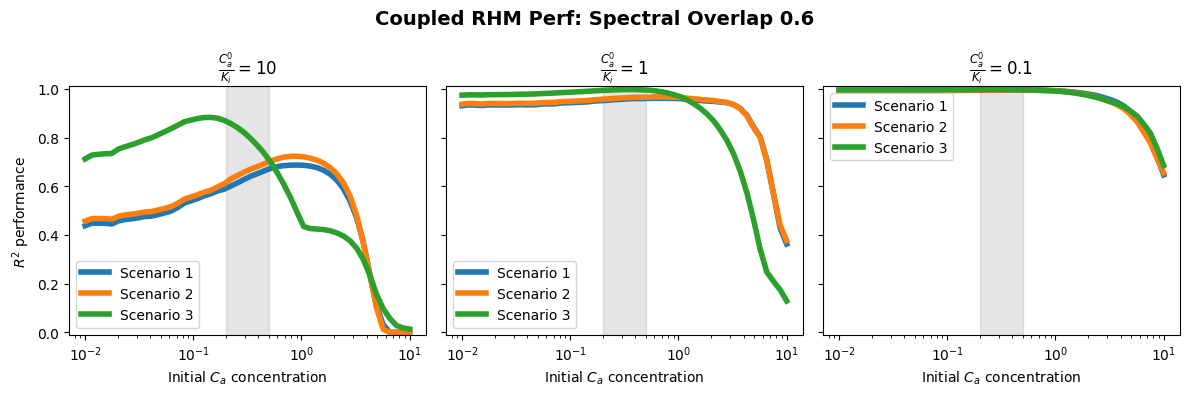

In [6]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
    couple_file_dict = full_coupled_dict[scenario_list[k]]
    
    C6_performance_list = couple_file_dict["0.6"]

    C6_unique_dict = {}
    for i in range(len(C6_performance_list)):
        name = C6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C6_unique_dict.keys()):
            C6_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C6_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

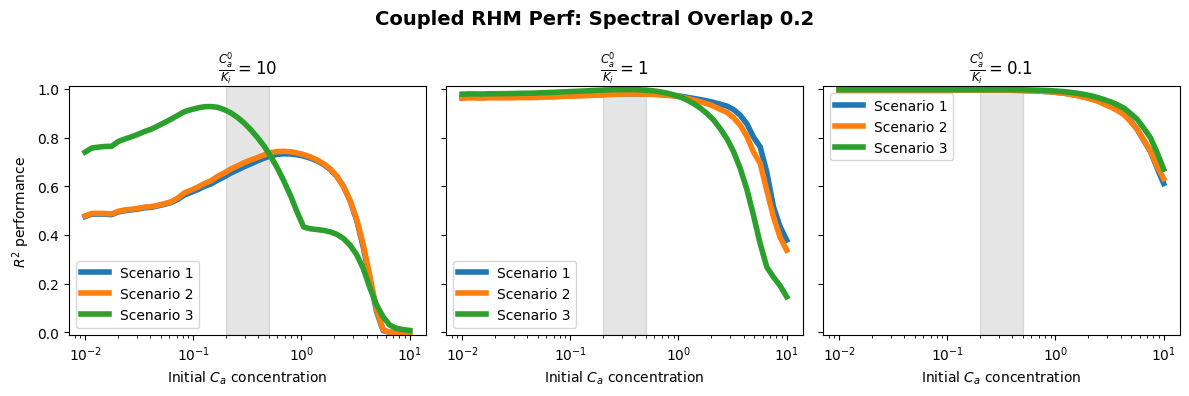

In [8]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
    couple_file_dict = full_coupled_dict[scenario_list[k]]
    
    C2_performance_list = couple_file_dict["0.2"]

    C2_unique_dict = {}
    for i in range(len(C2_performance_list)):
        name = C2_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C2_unique_dict.keys()):
            C2_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C2_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C2_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C2_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.2", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Iterative Raman Hybrid Model - SVD initialization

In [9]:
full_iterative_dict = {}

for j in range(len(scenario_list)):
    
    iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[j] + "/(322)_ANN"
    iterative_list = os.listdir(iterative_dir)

    iterative_file_dict = {}

    iterative_file_dict["0.2"] = []
    iterative_file_dict["0.6"] = []

    for i in range(len(iterative_list)):
        if ".pkl" in iterative_list[i]:
            spcovp = iterative_list[i].split("_")[4]
            iterative_file_dict[spcovp].append(iterative_list[i])
    
    full_iterative_dict[scenario_list[j]] = iterative_file_dict

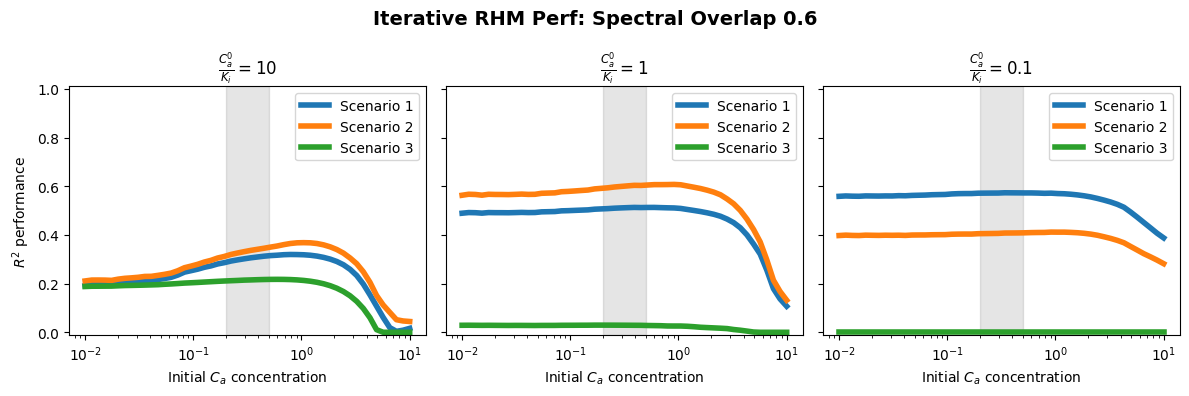

In [11]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I6_performance_list = iterative_file_dict["0.6"]

    I6_unique_dict = {}
    for i in range(len(I6_performance_list)):
        name = I6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I6_unique_dict.keys()):
            I6_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I6_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

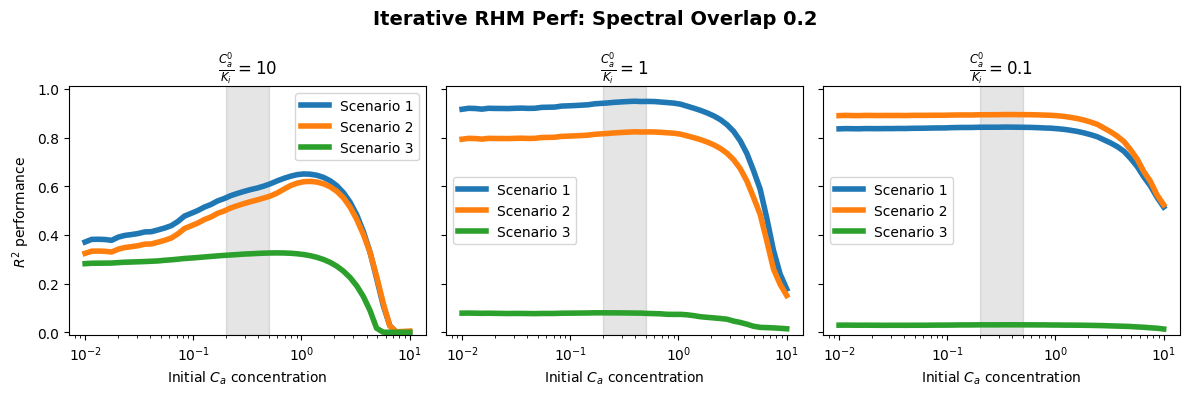

In [12]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I2_performance_list = iterative_file_dict["0.2"]

    I2_unique_dict = {}
    for i in range(len(I2_performance_list)):
        name = I2_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I2_unique_dict.keys()):
            I2_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I2_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I2_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I2_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.2", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Iterative Raman Hybrid Model - SIMPLISMA initialization

In [13]:
full_iterative_dict = {}

for j in range(len(scenario_list)):
    
    iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[j] + "/(322)_ANN"
    iterative_list = os.listdir(iterative_dir)

    iterative_file_dict = {}

    iterative_file_dict["0.2"] = []
    iterative_file_dict["0.6"] = []

    for i in range(len(iterative_list)):
        if ".pkl" in iterative_list[i]:
            spcovp = iterative_list[i].split("_")[4]
            iterative_file_dict[spcovp].append(iterative_list[i])
    
    full_iterative_dict[scenario_list[j]] = iterative_file_dict

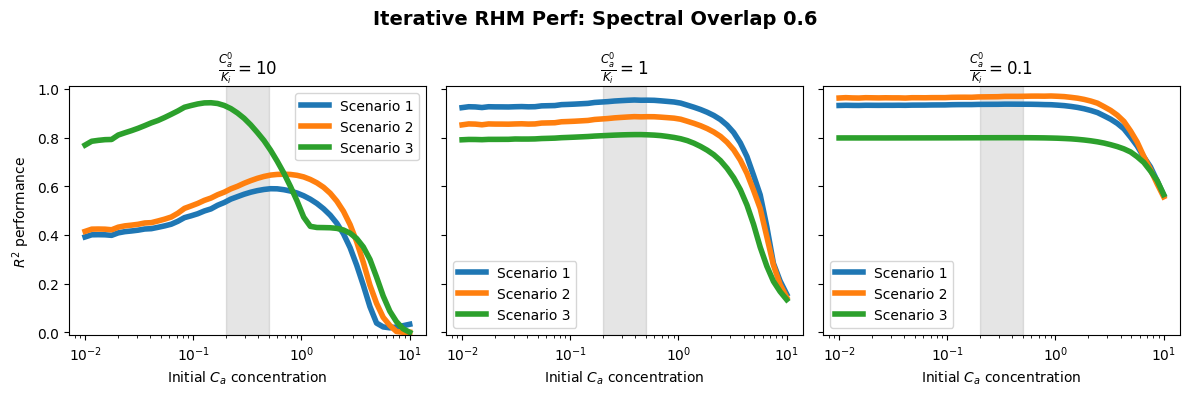

In [14]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I6_performance_list = iterative_file_dict["0.6"]

    I6_unique_dict = {}
    for i in range(len(I6_performance_list)):
        name = I6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I6_unique_dict.keys()):
            I6_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I6_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

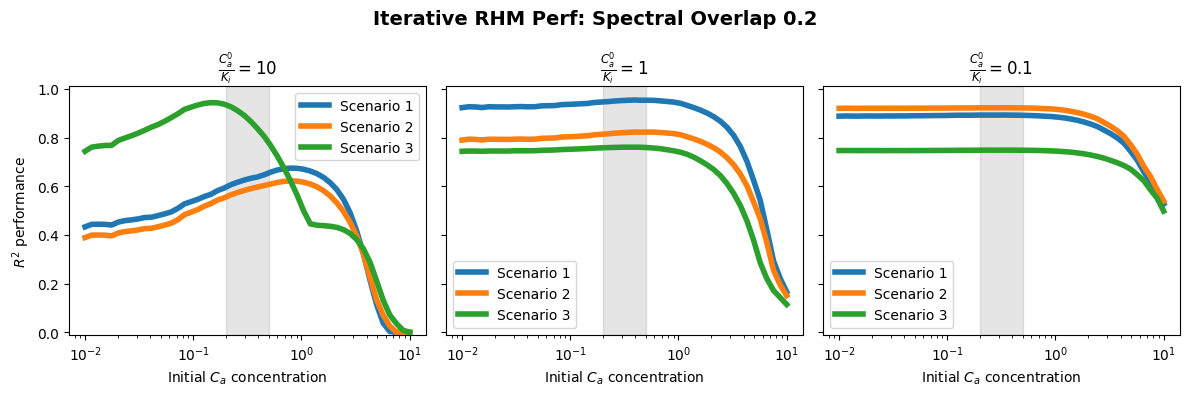

In [15]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[k] + "/(322)_ANN"
    iterative_file_dict = full_iterative_dict[scenario_list[k]]
    
    I2_performance_list = iterative_file_dict["0.2"]

    I2_unique_dict = {}
    for i in range(len(I2_performance_list)):
        name = I2_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(I2_unique_dict.keys()):
            I2_unique_dict[ky] = []

        filepath = os.path.join(iterative_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        I2_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(I2_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(I2_unique_dict[a]), axis = 0)
        if len(data) == 500:
            data = data[::10]

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Iterative RHM Perf: Spectral Overlap 0.2", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Coupled Raman Mechanistic Model

In [16]:
full_coupled_phenom_dict = {}

for j in range(len(scenario_list)):
    
    couple_dir = "Coupled Performance/Mechanistic model/" + scenario_list[j]
    coupled_list = os.listdir(couple_dir)

    couple_file_dict = {}

    couple_file_dict["0.2"] = []
    couple_file_dict["0.6"] = []

    for i in range(len(coupled_list)):
        if ".pkl" in coupled_list[i]:
            spcovp = coupled_list[i].split("_")[4]
            couple_file_dict[spcovp].append(coupled_list[i])
    
    full_coupled_phenom_dict[scenario_list[j]] = couple_file_dict

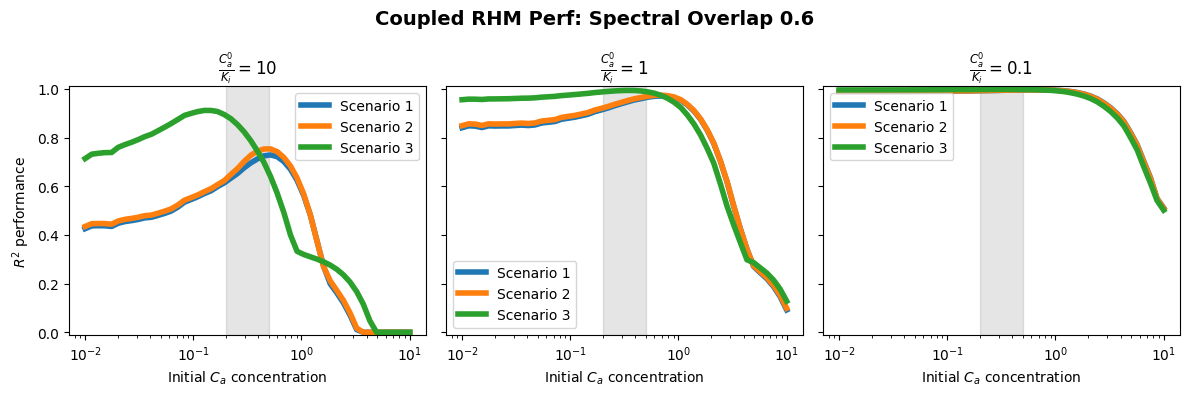

In [17]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Mechanistic model/" + scenario_list[k]
    couple_file_dict = full_coupled_phenom_dict[scenario_list[k]]
    
    C6_performance_list = couple_file_dict["0.6"]

    C6_unique_dict = {}
    for i in range(len(C6_performance_list)):
        name = C6_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C6_unique_dict.keys()):
            C6_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C6_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C6_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C6_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.6", fontweight = "bold", fontsize = 14)
plt.tight_layout()

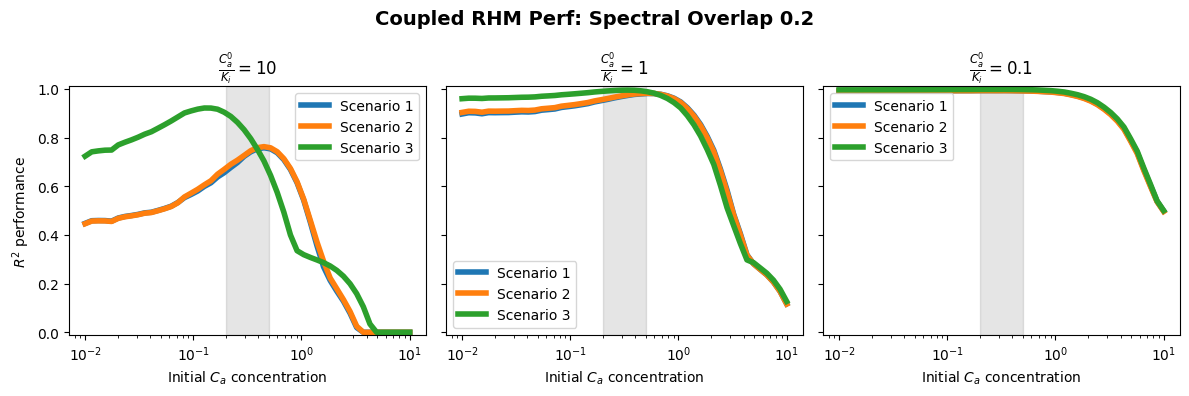

In [18]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4), sharex = True, sharey = True)

for k in range(len(scenario_list)):
    couple_dir = "Coupled Performance/Mechanistic model/" + scenario_list[k]
    couple_file_dict = full_coupled_phenom_dict[scenario_list[k]]
    
    C2_performance_list = couple_file_dict["0.2"]

    C2_unique_dict = {}
    for i in range(len(C2_performance_list)):
        name = C2_performance_list[i]
        k1 = float(name.split("_")[1])
        k2 = float(name.split("_")[2])
        ky = tuple([k1, k2])

        if ky not in list(C2_unique_dict.keys()):
            C2_unique_dict[ky] = []

        filepath = os.path.join(couple_dir, name)
        with open(filepath, "rb") as f:
            data = np.array(pickle.load(f)["conc_perf"])[:,0]

        C2_unique_dict[ky].append(data)
        
    row_title = [r"$\frac{C_a^0}{K_i} = 10$", r"$\frac{C_a^0}{K_i} = 1$", r"$\frac{C_a^0}{K_i} = 0.1$"]

    for a in list(C2_unique_dict.keys()):
        xind = int(2 + np.log10(a[0]/5))

        data = np.mean(np.array(C2_unique_dict[a]), axis = 0)

        axs[xind].plot(C1_range, data, label = scenario_list[k], linewidth = 4)
        axs[xind].legend()
        axs[xind].set_xscale("log")
        if k == 0:
            axs[xind].axvspan(0.2, 0.5, color = "k", alpha = 0.1)
        axs[xind].set_ylim([-0.01, 1.01])
        axs[xind].set_xlabel("Initial $C_a$ concentration")
        axs[xind].set_title(row_title[xind])
        if xind == 0:
            axs[xind].set_ylabel("$R^2$ performance")
        
fig.suptitle("Coupled RHM Perf: Spectral Overlap 0.2", fontweight = "bold", fontsize = 14)
plt.tight_layout()

# Image Generation for manuscript

## Figure 3: CRHM vs IRHM-SVD

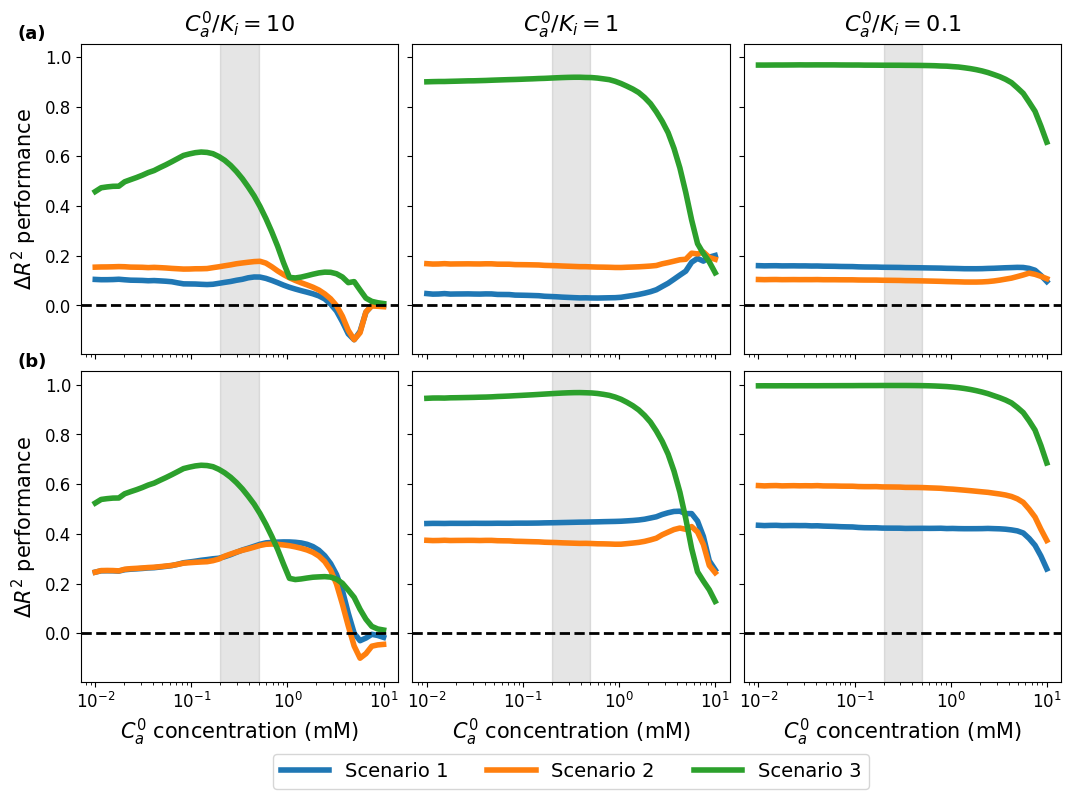

In [19]:
# ── Global font size ─────────────────────────────────────────────────────────
FONT_SIZE = 11
plt.rcParams.update({
    "font.size":        FONT_SIZE,
    "axes.titlesize":   FONT_SIZE,
    "axes.labelsize":   FONT_SIZE,
    "xtick.labelsize":  FONT_SIZE + 1,
    "ytick.labelsize":  FONT_SIZE + 1,
    "legend.fontsize":  FONT_SIZE + 1,
})

# ── Layout constants ──────────────────────────────────────────────────────────
spc_list   = ["0.2", "0.6"]
row_titles = [
    r"$C_a^0/K_i = 10$",
    r"$C_a^0/K_i = 1$",
    r"$C_a^0/K_i = 0.1$",
]
fig_labels = ["(a)", "(b)"]
NROWS, NCOLS = 2, 3

# ── Figure and GridSpec ───────────────────────────────────────────────────────
# Structure:  NROWS data rows  +  1 legend row
#             1 row-title col  +  NCOLS data cols
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    nrows=NROWS + 1,
    ncols=NCOLS + 1,
    height_ratios=[1] * NROWS + [0.12],
    width_ratios=[0.04] + [1] * NCOLS,   # narrow placeholder col for row titles
    hspace=0.08,
    wspace=0.06,
)

# ── Data axes ────────────────────────────────────────────────────────────────
axs = np.empty((NROWS, NCOLS), dtype=object)
shared_x = shared_y = None

for row in range(NROWS):
    for col in range(NCOLS):
        ax = fig.add_subplot(
            gs[row, col + 1],
            sharex=shared_x,
            sharey=shared_y,
        )
        axs[row, col] = ax
        if shared_x is None:
            shared_x = ax
            shared_y = ax
        if row < NROWS - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        if col > 0:
            plt.setp(ax.get_yticklabels(), visible=False)

# ── Row titles: placed via fig.text in figure coordinates ────────────────────
# Get the vertical midpoint of each row's axes in figure coords, then place
# text just to the left of the leftmost data column.
fig.canvas.draw()  # needed so get_position() returns real values

for row, title in enumerate(row_titles):
    ax = axs[0, row]
    pos = ax.get_position()                      # Bbox in figure coords
    y_mid = pos.y1 + 0.02               # vertical centre of row
    x_left = (pos.x0 + pos.x1)/2                     # nudge left of the data panel

    fig.text(x_left, y_mid, title,
             ha="center", va="center",
             fontsize=16)

# ── Figure labels (a) / (b) in top-left corner of top panels ─────────────────
for col, label in enumerate(fig_labels):
    axs[0, col].text(-0.2, 1.06, label,
                     transform=axs[col, 0].transAxes,
                     fontsize=13, fontweight="bold",
                     va="top", ha="left")
# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(NROWS):
    axs[row, 0].set_ylabel("$ \Delta R^2$ performance", fontsize = 15)

for col in range(NCOLS):
    axs[NROWS-1, col].set_xlabel("$C^0_a$ concentration (mM)", fontsize = 15)

# ── Data loading and plotting ─────────────────────────────────────────────────
handles, labels = [], []

for l in range(NROWS):
    key = spc_list[l]
    for k in range(len(scenario_list)):
        couple_dir = "Coupled Performance/Hybrid Model/" + scenario_list[k] + "/(322)_ANN"
        C2_performance_list = full_coupled_dict[scenario_list[k]][key]
        C2_unique_dict = {}
        for name in C2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            C2_unique_dict.setdefault(ky, [])
            with open(os.path.join(couple_dir, name), "rb") as f:
                C2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        iterative_dir = "Iterative Performance/SVD_init/" + scenario_list[k] + "/(322)_ANN"
        I2_performance_list = full_iterative_dict[scenario_list[k]][key]
        I2_unique_dict = {}
        for name in I2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            I2_unique_dict.setdefault(ky, [])
            with open(os.path.join(iterative_dir, name), "rb") as f:
                I2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        for a in C2_unique_dict:
            xind = int(2 + np.log10(a[0] / 5))
            C_data = np.mean(np.array(C2_unique_dict[a]), axis=0)
            I_data = np.mean(np.array(I2_unique_dict[a]), axis=0)
            if len(I_data) == 500:
                I_data = I_data[::10]

            ax = axs[l, xind]
            line, = ax.plot(C1_range, C_data - I_data,
                            label=scenario_list[k], linewidth=4)
            ax.set_xscale("log")
            #ax.set_ylim([-1.05, 1.05])

            if k == 2:
                ax.axvspan(0.2, 0.5, color="k", alpha=0.1)
                ax.axhline(0, linestyle="--", color="k", linewidth=2)

            if l == 0 and scenario_list[k] not in labels:
                handles.append(line)
                labels.append(scenario_list[k])

# ── Legend: fig.legend anchored below the bottom data panels ─────────────────
# Re-draw so axis positions are finalised before we compute coordinates
fig.canvas.draw()

bottom_pos = axs[NROWS - 1, 0].get_position()
x_centre   = (axs[NROWS - 1, 0].get_position().x0 +
               axs[NROWS - 1, NCOLS - 1].get_position().x1) / 2
y_legend   = bottom_pos.y0 - 0.1   # clear below x-axis tick labels + label

fig.legend(
    handles, labels,
    loc="center",
    ncol=len(scenario_list),
    frameon=True,
    handlelength=2.5,
    bbox_to_anchor=(x_centre, y_legend),
    bbox_transform=fig.transFigure, fontsize = 14
)

#plt.savefig("Coup_Iter_SVD_v2.svg", dpi = 300, bbox_inches="tight")
plt.show()

## Figure 4: CRHM vs IRHM-SIMPLISMA

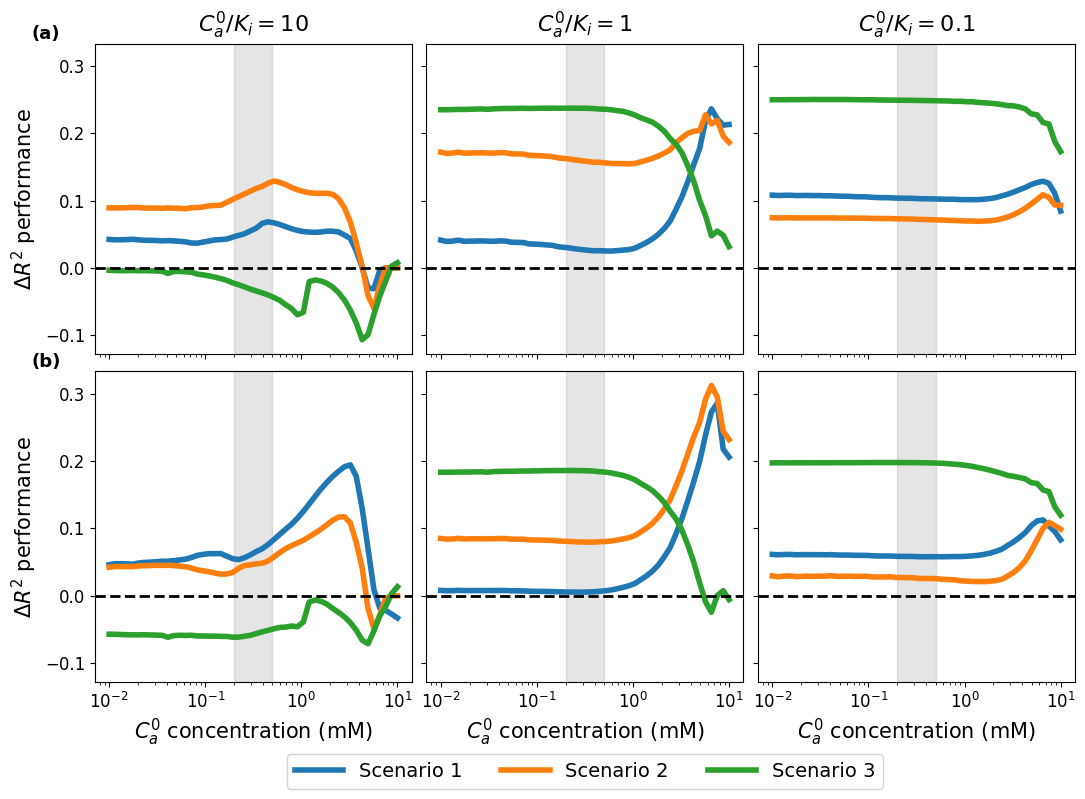

In [20]:
# ── Global font size ─────────────────────────────────────────────────────────
FONT_SIZE = 11
plt.rcParams.update({
    "font.size":        FONT_SIZE,
    "axes.titlesize":   FONT_SIZE,
    "axes.labelsize":   FONT_SIZE,
    "xtick.labelsize":  FONT_SIZE + 1,
    "ytick.labelsize":  FONT_SIZE + 1,
    "legend.fontsize":  FONT_SIZE + 1,
})

# ── Layout constants ──────────────────────────────────────────────────────────
spc_list   = ["0.2", "0.6"]
row_titles = [
    r"$C_a^0/K_i = 10$",
    r"$C_a^0/K_i = 1$",
    r"$C_a^0/K_i = 0.1$",
]
fig_labels = ["(a)", "(b)"]
NROWS, NCOLS = 2, 3

# ── Figure and GridSpec ───────────────────────────────────────────────────────
# Structure:  NROWS data rows  +  1 legend row
#             1 row-title col  +  NCOLS data cols
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    nrows=NROWS + 1,
    ncols=NCOLS + 1,
    height_ratios=[1] * NROWS + [0.12],
    width_ratios=[0.04] + [1] * NCOLS,   # narrow placeholder col for row titles
    hspace=0.08,
    wspace=0.06,
)

# ── Data axes ────────────────────────────────────────────────────────────────
axs = np.empty((NROWS, NCOLS), dtype=object)
shared_x = shared_y = None

for row in range(NROWS):
    for col in range(NCOLS):
        ax = fig.add_subplot(
            gs[row, col + 1],
            sharex=shared_x,
            sharey=shared_y,
        )
        axs[row, col] = ax
        if shared_x is None:
            shared_x = ax
            shared_y = ax
        if row < NROWS - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        if col > 0:
            plt.setp(ax.get_yticklabels(), visible=False)

# ── Row titles: placed via fig.text in figure coordinates ────────────────────
# Get the vertical midpoint of each row's axes in figure coords, then place
# text just to the left of the leftmost data column.
fig.canvas.draw()  # needed so get_position() returns real values

for row, title in enumerate(row_titles):
    ax = axs[0, row]
    pos = ax.get_position()                      # Bbox in figure coords
    y_mid = pos.y1 + 0.02               # vertical centre of row
    x_left = (pos.x0 + pos.x1)/2                     # nudge left of the data panel

    fig.text(x_left, y_mid, title,
             ha="center", va="center",
             fontsize=16)

# ── Figure labels (a) / (b) in top-left corner of top panels ─────────────────
for col, label in enumerate(fig_labels):
    axs[0, col].text(-0.2, 1.06, label,
                     transform=axs[col, 0].transAxes,
                     fontsize=13, fontweight="bold",
                     va="top", ha="left")

# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(NROWS):
    axs[row, 0].set_ylabel("$ \Delta R^2$ performance", fontsize = 15)

for col in range(NCOLS):
    axs[NROWS-1, col].set_xlabel("$C^0_a$ concentration (mM)", fontsize = 15)

# ── Data loading and plotting ─────────────────────────────────────────────────
handles, labels = [], []

for l in range(NROWS):
    key = spc_list[l]
    for k in range(len(scenario_list)):
        couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
        C2_performance_list = full_coupled_dict[scenario_list[k]][key]
        C2_unique_dict = {}
        for name in C2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            C2_unique_dict.setdefault(ky, [])
            with open(os.path.join(couple_dir, name), "rb") as f:
                C2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        iterative_dir = "Iterative Performance/SIMPLISMA_init/" + scenario_list[k] + "/(322)_ANN"
        I2_performance_list = full_iterative_dict[scenario_list[k]][key]
        I2_unique_dict = {}
        for name in I2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            I2_unique_dict.setdefault(ky, [])
            with open(os.path.join(iterative_dir, name), "rb") as f:
                I2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        for a in C2_unique_dict:
            xind = int(2 + np.log10(a[0] / 5))
            C_data = np.mean(np.array(C2_unique_dict[a]), axis=0)
            I_data = np.mean(np.array(I2_unique_dict[a]), axis=0)
            if len(I_data) == 500:
                I_data = I_data[::10]

            ax = axs[l, xind]
            line, = ax.plot(C1_range, C_data - I_data,
                            label=scenario_list[k], linewidth=4)
            ax.set_xscale("log")
            #ax.set_ylim([-1.05, 1.05])

            if k == 2:
                ax.axvspan(0.2, 0.5, color="k", alpha=0.1)
                ax.axhline(0, linestyle="--", color="k", linewidth=2)

            if l == 0 and scenario_list[k] not in labels:
                handles.append(line)
                labels.append(scenario_list[k])

# ── Legend: fig.legend anchored below the bottom data panels ─────────────────
# Re-draw so axis positions are finalised before we compute coordinates
fig.canvas.draw()

bottom_pos = axs[NROWS - 1, 0].get_position()
x_centre   = (axs[NROWS - 1, 0].get_position().x0 +
               axs[NROWS - 1, NCOLS - 1].get_position().x1) / 2
y_legend   = bottom_pos.y0 - 0.1   # clear below x-axis tick labels + label

fig.legend(
    handles, labels,
    loc="center",
    ncol=len(scenario_list),
    frameon=True,
    handlelength=2.5,
    bbox_to_anchor=(x_centre, y_legend),
    bbox_transform=fig.transFigure, fontsize = 14
)

#plt.savefig("Coup_Iter_SML_v2.svg", dpi = 300, bbox_inches="tight")
plt.show()

## Figure 5: CRHM vs CRMM

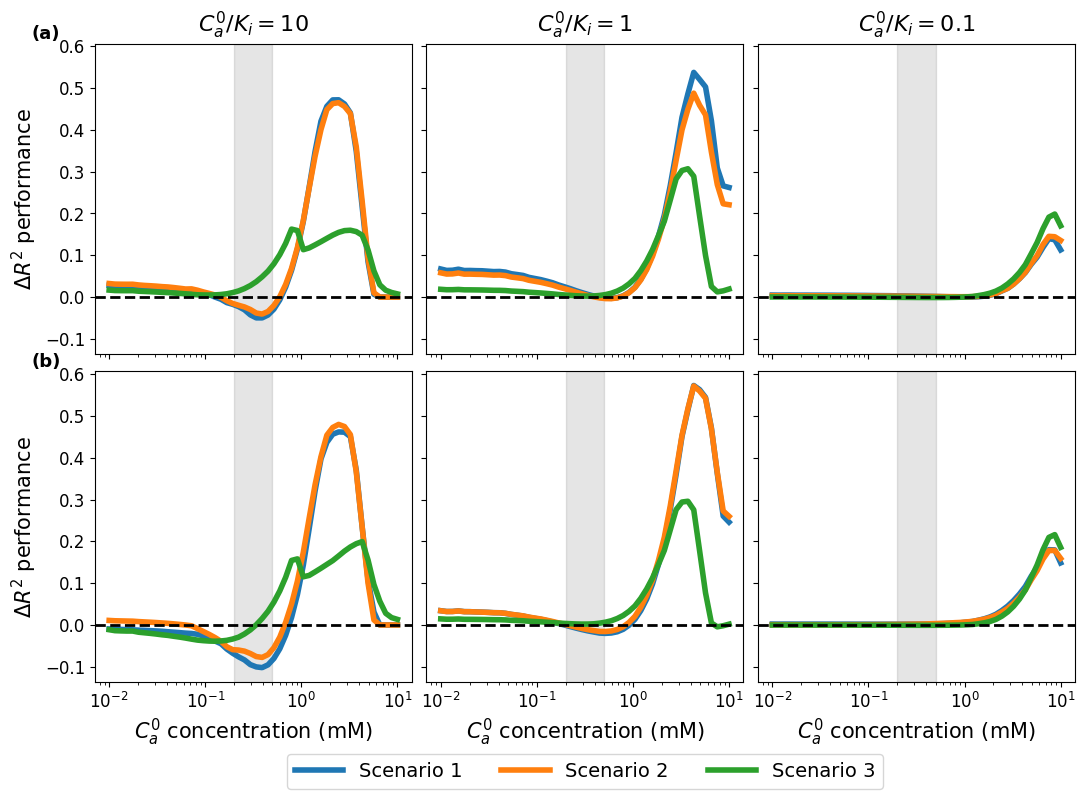

In [21]:
# ── Global font size ─────────────────────────────────────────────────────────
FONT_SIZE = 11
plt.rcParams.update({
    "font.size":        FONT_SIZE,
    "axes.titlesize":   FONT_SIZE,
    "axes.labelsize":   FONT_SIZE,
    "xtick.labelsize":  FONT_SIZE + 1,
    "ytick.labelsize":  FONT_SIZE + 1,
    "legend.fontsize":  FONT_SIZE + 1,
})

# ── Layout constants ──────────────────────────────────────────────────────────
spc_list   = ["0.2", "0.6"]
row_titles = [
    r"$C_a^0/K_i = 10$",
    r"$C_a^0/K_i = 1$",
    r"$C_a^0/K_i = 0.1$",
]
fig_labels = ["(a)", "(b)"]
NROWS, NCOLS = 2, 3

# ── Figure and GridSpec ───────────────────────────────────────────────────────
# Structure:  NROWS data rows  +  1 legend row
#             1 row-title col  +  NCOLS data cols
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(
    nrows=NROWS + 1,
    ncols=NCOLS + 1,
    height_ratios=[1] * NROWS + [0.12],
    width_ratios=[0.04] + [1] * NCOLS,   # narrow placeholder col for row titles
    hspace=0.08,
    wspace=0.06,
)

# ── Data axes ────────────────────────────────────────────────────────────────
axs = np.empty((NROWS, NCOLS), dtype=object)
shared_x = shared_y = None

for row in range(NROWS):
    for col in range(NCOLS):
        ax = fig.add_subplot(
            gs[row, col + 1],
            sharex=shared_x,
            sharey=shared_y,
        )
        axs[row, col] = ax
        if shared_x is None:
            shared_x = ax
            shared_y = ax
        if row < NROWS - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        if col > 0:
            plt.setp(ax.get_yticklabels(), visible=False)

# ── Row titles: placed via fig.text in figure coordinates ────────────────────
# Get the vertical midpoint of each row's axes in figure coords, then place
# text just to the left of the leftmost data column.
fig.canvas.draw()  # needed so get_position() returns real values

for row, title in enumerate(row_titles):
    ax = axs[0, row]
    pos = ax.get_position()                      # Bbox in figure coords
    y_mid = pos.y1 + 0.02               # vertical centre of row
    x_left = (pos.x0 + pos.x1)/2                     # nudge left of the data panel

    fig.text(x_left, y_mid, title,
             ha="center", va="center",
             fontsize=16)

# ── Figure labels (a) / (b) in top-left corner of top panels ─────────────────
for col, label in enumerate(fig_labels):
    axs[0, col].text(-0.2, 1.06, label,
                     transform=axs[col, 0].transAxes,
                     fontsize=13, fontweight="bold",
                     va="top", ha="left")

# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(NROWS):
    axs[row, 0].set_ylabel("$ \Delta R^2$ performance", fontsize = 15)

for col in range(NCOLS):
    axs[NROWS-1, col].set_xlabel("$C^0_a$ concentration (mM)", fontsize = 15)

# ── Data loading and plotting ─────────────────────────────────────────────────
handles, labels = [], []

for l in range(NROWS):
    key = spc_list[l]
    for k in range(len(scenario_list)):
        couple_dir = "Coupled Performance/Hybrid model/" + scenario_list[k] + "/(322)_ANN"
        C2_performance_list = full_coupled_dict[scenario_list[k]][key]
        C2_unique_dict = {}
        for name in C2_performance_list:
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = (k1, k2)
            C2_unique_dict.setdefault(ky, [])
            with open(os.path.join(couple_dir, name), "rb") as f:
                C2_unique_dict[ky].append(
                    np.array(pickle.load(f)["conc_perf"])[:, 0])

        couple_phenom_dir = "Coupled Performance/Mechanistic model/" + scenario_list[k]
        couple_phenom_file_dict = full_coupled_phenom_dict[scenario_list[k]]
        CP6_performance_list = couple_phenom_file_dict["0.2"]
        CP6_unique_dict = {}
        for i in range(len(CP6_performance_list)):
            name = CP6_performance_list[i]
            k1 = float(name.split("_")[1])
            k2 = float(name.split("_")[2])
            ky = tuple([k1, k2])
            if ky not in list(CP6_unique_dict.keys()):
                CP6_unique_dict[ky] = []
            filepath = os.path.join(couple_phenom_dir, name)
            with open(filepath, "rb") as f:
                data = np.array(pickle.load(f)["conc_perf"])[:,0]
            CP6_unique_dict[ky].append(data)

        for a in C2_unique_dict:
            xind = int(2 + np.log10(a[0] / 5))
            C_data = np.mean(np.array(C2_unique_dict[a]), axis=0)
            I_data = np.mean(np.array(CP6_unique_dict[a]), axis=0)

            ax = axs[l, xind]
            line, = ax.plot(C1_range, C_data - I_data,
                            label=scenario_list[k], linewidth=4)
            ax.set_xscale("log")
            #ax.set_ylim([-1.05, 1.05])

            if k == 2:
                ax.axvspan(0.2, 0.5, color="k", alpha=0.1)
                ax.axhline(0, linestyle="--", color="k", linewidth=2)

            if l == 0 and scenario_list[k] not in labels:
                handles.append(line)
                labels.append(scenario_list[k])

# ── Legend: fig.legend anchored below the bottom data panels ─────────────────
# Re-draw so axis positions are finalised before we compute coordinates
fig.canvas.draw()

bottom_pos = axs[NROWS - 1, 0].get_position()
x_centre   = (axs[NROWS - 1, 0].get_position().x0 +
               axs[NROWS - 1, NCOLS - 1].get_position().x1) / 2
y_legend   = bottom_pos.y0 - 0.1   # clear below x-axis tick labels + label

fig.legend(
    handles, labels,
    loc="center",
    ncol=len(scenario_list),
    frameon=True,
    handlelength=2.5,
    bbox_to_anchor=(x_centre, y_legend),
    bbox_transform=fig.transFigure, fontsize = 14
)

#plt.savefig("Coup_HM_PM_v2.svg", dpi = 300, bbox_inches="tight")
plt.show()